# Example application of the neurolinguistics pipeline 

<b>Purpose:</b> This notebook generates synthetic transcripts and computes speech signatures using the GPT-5 features selected by our neurolinguistics pipeline. It is intended as a practical example of repository usage rather than a reproduction of the reported findings. The synthetic transcripts generated by GPT-5 here are intended to represent prototypical participants from the NTN<sub>A-</sub> (low amygdala reactivity) and NTN<sub>A+</sub> (high amygdala reactivity) biotype subgroups during the placebo and MDMA conditions. 

In [1]:
import utils
import transcribe
import featurize
import visualize

import os
import json
import requests
import numpy as np
import pandas as pd

In [2]:
biotypes = ["low", "high"]
conditions = ["placebo", "mdma_high"]

n_blocks = 5
min_dur = 10
max_dur = 30

data_path = "example/data"
table_path = "example/tables"
feature_path = "example/features"
figure_path = "example/figures"

In [3]:
gpt_top_params = {
                    "placebo":   {"low_n_vars": 7,
                                  "high_n_vars": 10,
                                  "low_n_iter": 0,
                                  "high_n_iter": 1},
    
                    "mdma_high": {"low_n_vars": 3,
                                  "high_n_vars": 6,
                                  "low_n_iter": 1,
                                  "high_n_iter": 1}
                 }

gpt_top_features = {
                     "placebo": {
                         "low": ["gpt5_emotional_bandwidth_allocation"],
                         "high": ["gpt5_attention_state_oscillation",
                                  "gpt5_physiological_monitoring_hypotheses",
                                  "gpt5_performance_vigilance", 
                                  "gpt5_professional_boundary_awareness"]
                     },
                      "mdma_high": {
                         "low": ["gpt5_boundary_conscious_social_restraint"],
                         "high": ["gpt5_open_boundary_openness",
                                  "gpt5_breath_self_regulation", 
                                  "gpt5_systems_policy_orientation"]
                      }
    
                   }

In [4]:
api_url = "https://aiapi-prod.stanford.edu/v1/chat/completions"
with open("../private/secureGPT.txt") as file:
    api_key = file.read()
    
gpt5_headers = {"Content-Type": "application/json",
                "Authorization": f"Bearer {api_key}"}

## Selected speech features

In [5]:
features = {}
for condition in conditions:
    print("-"*100 + f"\nSPEECH SIGNATURES FOR {condition.upper()}\n" + "-" * 100)
    features[condition] = {}
    for biotype in biotypes:
        file_name = f"{data_path}/synthetic_transcript_{condition}_{biotype}.json"

        n_vars = gpt_top_params[condition][f"{biotype}_n_vars"]
        n_iter = gpt_top_params[condition][f"{biotype}_n_iter"]
        
        gpt_json_file = f"manuscript/features/gpt5/iteration_{n_iter:02d}/{condition}/{biotype}/gpt5_{condition}_{biotype}_{n_vars:02d}.json"
        candidate_features = featurize.load_gpt_json(gpt_json_file)
        
        features[condition][biotype] = {"titles": {}, "descriptions": {}}
        for var in gpt_top_features[condition][biotype]:
            features[condition][biotype]["titles"][var] = candidate_features["titles"][var]
            features[condition][biotype]["descriptions"][var] = candidate_features["descriptions"][var]

        print("-"*70 + f"\n{biotype.upper()} BIOTYPE FEATURES\n" + "-" * 70)
        for var, title in features[condition][biotype]["titles"].items():
            title = title.upper()
            description = features[condition][biotype]["descriptions"][var]
            print(f"{title}: {description}\n")

----------------------------------------------------------------------------------------------------
SPEECH SIGNATURES FOR PLACEBO
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------
LOW BIOTYPE FEATURES
----------------------------------------------------------------------
STRUCTURED EMOTIONAL BANDWIDTH ALLOCATION: LOW participants explicitly allocate mental “lanes” to feelings, structuring bandwidth for deliberate emotional processing during and after sessions. They describe an added or reallocated “lane for feeling,” intentional bandwidth reserved for emotions, and compartmentalization that allows them to balance tasks and feelings. This framework supports deep emotional work and a sustained afterglow (e.g., week-long openness, more embracing with family), making the experience not just acute but integrative. HIGH transcripts do not foreground this kind of delibera

## Synthetic transcript generation

In [6]:
def collapse_dict(features, condition_to_remove, biotype_to_remove):
    
    dict = {"titles": {}, "descriptions": {}}
    for condition_key, condition_dict in features.items():
        for biotype_key, content in condition_dict.items():
            if condition_key == condition_to_remove and biotype_key == biotype_to_remove:
                continue
            dict["titles"].update(content.get("titles", {}))
            dict["descriptions"].update(content.get("descriptions", {}))
            
    return dict

In [7]:
prompt = """
Generate a transcript for a [BIOTYPE] biotype individual whose speech is characterized by the features below during a [CONDITION] session. 
The first set of features labeled 'FEATURES PRESENT IN THE TRANSCRIPT' should be strongly present in the transcript.
Each of the features that are present in the person's speech should be present to a similarly high degree.
The second set of features labeled 'FEATURES NOT PRESENT IN THE TRANSCRIPT' should NOT be present in the transcript.
Show only this individual's speech in the transcript, though it should be as if this person were conversing with someone interested in their experience.
Some features may describe how the individual relates interpersonally with the person they are speaking with.
The individual speaking may not be consciously aware that certain features are present in their speech.
The features are expected to be present in the psycholinguistic style of the individual's speech, not just the content of their speech.
The transcript should take 10 minutes to be spoken aloud.

FEATURES PRESENT IN THE TRANSCRIPT:
[FEATURES_PRESENT]

FEATURES NOT PRESENT IN THE TRANSCRIPT:
[FEATURES_ABSENT]
"""

for condition in conditions:
    for biotype_i, biotype in enumerate(biotypes):

        features_present = json.dumps(features[condition][biotype], indent=4)
        features_absent = json.dumps(features[condition][biotypes[biotype_i-1]], indent=4)
        prompt_for_condition_and_biotype = prompt.replace("[BIOTYPE]", biotype.upper()).replace("[CONDITION]", condition.upper())
        prompt_for_condition_and_biotype = prompt_for_condition_and_biotype.replace("[FEATURES_PRESENT]", features_present)
        prompt_for_condition_and_biotype = prompt_for_condition_and_biotype.replace("[FEATURES_ABSENT]", features_absent)
        
        print("-"*100 + f"\nGENERATING A SYNTHETIC TRANSCRIPT REPRESENTING THE {biotype.upper()} BIOTYPE DURING {condition.upper()}\n" + "-" * 100)
        print(prompt_for_condition_and_biotype)
        print()

        file_name = f"{data_path}/synthetic_transcript_{condition}_{biotype}.json"
        if not os.path.exists(file_name):
            payload = {"model": "gpt-5",
                       "stream": False,
                       "messages": [{"role": "user", "content": prompt_for_condition_and_biotype}]}
            response = requests.post(api_url, headers=gpt5_headers, json=payload)
            with open(file_name, "w") as file:
                json.dump(response.json(), file, indent=4)

----------------------------------------------------------------------------------------------------
GENERATING A SYNTHETIC TRANSCRIPT REPRESENTING THE LOW BIOTYPE DURING PLACEBO
----------------------------------------------------------------------------------------------------

Generate a transcript for a LOW biotype individual whose speech is characterized by the features below during a PLACEBO session. 
The first set of features labeled 'FEATURES PRESENT IN THE TRANSCRIPT' should be strongly present in the transcript.
Each of the features that are present in the person's speech should be present to a similarly high degree.
The second set of features labeled 'FEATURES NOT PRESENT IN THE TRANSCRIPT' should NOT be present in the transcript.
Show only this individual's speech in the transcript, though it should be as if this person were conversing with someone interested in their experience.
Some features may describe how the individual relates interpersonally with the person they are 

## Preprocessing the transcripts

In [8]:
transcript_dfs = {max_dur: {}}
participant_i = 1
for condition_i, condition in enumerate(conditions):
    for biotype in biotypes:
        session = f"P{participant_i:03d}_S{condition_i+1}"
        
        # Load synthetic transcript texts generated by GPT-5
        file_name = f"{data_path}/synthetic_transcript_{condition}_{biotype}.json"
        with open(file_name, "r") as file:
            data_json = json.load(file)
        transcript = data_json["choices"][0]["message"]["content"]
        print("-"*100 + f"\nSYNTHETIC TRANSCRIPT REPRESENTING THE {biotype.upper()} BIOTYPE DURING {condition.upper()}\n" + "-" * 100)
        print(transcript)
        print()

        # Split into lines up to 50 words, the approximate mean per utterance in our study data
        window_size = 50
        words = transcript.split()
        lines = [" ".join(words[i:i + window_size]) for i in range(0, len(words), window_size)]
        transcript_df = pd.DataFrame({"ID": [f"{session}_{i}" for i in range(len(lines))],
                                      "CONDITION": [condition]*len(lines),
                                      "BIOTYPE": [biotype]*len(lines),
                                      "SESSION": [session]*len(lines),
                                      "SPEAKER": ["PARTICIPANT"]*len(lines),
                                      "TEXT": lines,
                                      "DURATION": [30]*len(lines)})
        transcript_dfs[max_dur][session] = transcript_df
        participant_i += 1

----------------------------------------------------------------------------------------------------
SYNTHETIC TRANSCRIPT REPRESENTING THE LOW BIOTYPE DURING PLACEBO
----------------------------------------------------------------------------------------------------
Yeah, I’m good to start. The way I approached today was pretty deliberate on the emotional side. Before we began, I made a little mental dashboard, and I carved out a lane just for feeling. I picture it like a highway with dedicated lanes: one lane for anything you’d ask me to do, one lane for the basic “being here,” and then a clear lane for feelings. I also kept a shoulder on that highway, a safe pull-off where I could park something that felt big and leave it for later. That’s become a habit for me—if I give emotions their own bandwidth, they don’t have to fight the rest of my life to get airtime. I can keep them flowing without them taking over.

During the session, I intentionally opened that feeling lane about a quart

In [9]:
speech_line_df = transcribe.combine_transcripts2df(transcript_dfs, max_dur=max_dur)
speech_line_df = transcribe.filter_line_df(speech_line_df, speaker_filter="PARTICIPANT", min_dur_filter=min_dur)
speech_line_df.columns = [c.lower() for c in speech_line_df.columns]
speech_block_df, speech_line_df = transcribe.load_blocks(speech_line_df, n_blocks=n_blocks, min_dur=min_dur)
speech_line_df = transcribe.load_index(speech_line_df, n_blocks=n_blocks)
speech_line_df.to_csv(f"{data_path}/speech_line_df.csv")
speech_line_df[["session", "condition", "biotype", "block", "text"]].head()

,session,condition,biotype,block,text
P001_S1_B1_L1,P001_S1,placebo,low,1,"Yeah, I’m good to start. The way I approached ..."
P001_S1_B1_L2,P001_S1,placebo,low,1,"me to do, one lane for the basic “being here,”..."
P001_S1_B1_L3,P001_S1,placebo,low,1,"their own bandwidth, they don’t have to fight ..."
P001_S1_B1_L4,P001_S1,placebo,low,1,light on. Even though my body felt pretty neut...
P001_S1_B1_L5,P001_S1,placebo,low,1,tagged it and placed it on that shoulder to re...


## Featurizing the transcripts

In [10]:
manuscript_feature_path = "manuscript/features"
with open(f"{manuscript_feature_path}/gpt5/gpt5_prompt_01_quantify_features.txt") as file:
    prompt = file.read()

sessions = sorted(list(set(speech_line_df["session"])))
for condition in conditions:
    for biotype in biotypes:

        features_for_condition_and_biotype = json.dumps(features[condition][biotype], indent=4)       
        prompt_for_feature_set = prompt.replace("[DIFFERENTIATORS]", features_for_condition_and_biotype)
        prompt_for_feature_set = prompt_for_feature_set.replace("[N_VARS]", f"{n_vars:02d}") 
        
        for session in sessions:
            
            session_df = speech_line_df[speech_line_df["session"] == session]
            texts = "\n\n--------------------\n\n".join([f"{id}: {text}" for id, text in zip(session_df.index, session_df["text"])])
            prompt_for_session = prompt_for_feature_set + texts

            path_for_session = f"{feature_path}/{condition}/{biotype}"
            if not os.path.exists(path_for_session):
                os.makedirs(path_for_session)
            file_name = f"{path_for_session }/synthetic_features_{condition}_{biotype}_{session}.json"
            if not os.path.exists(file_name):
                payload = {"model": "gpt-5",
                           "stream": False,
                           "messages": [{"role": "user", "content": prompt_for_session}]}
                response = requests.post(api_url, headers=gpt5_headers, json=payload)
                
                with open(file_name, "w") as file:
                    json.dump(response.json(), file, indent=4)

In [11]:
for condition in conditions:
    for biotype in biotypes:

        feature_quant_files = sorted([f"{feature_path}/{condition}/{biotype}/{file}" for file in os.listdir(f"{feature_path}/{condition}/{biotype}") if file.endswith(".json")])
        speech_line_df = featurize.load_gpt_feature_files(feature_quant_files, speech_line_df,
                                                          headers=["gpt5_ID"] + gpt_top_features[condition][biotype])

speech_line_df[[var for var in speech_line_df.columns if var.startswith("gpt5_")]].head()

,gpt5_emotional_bandwidth_allocation,gpt5_attention_state_oscillation,gpt5_physiological_monitoring_hypotheses,gpt5_performance_vigilance,gpt5_professional_boundary_awareness,gpt5_boundary_conscious_social_restraint,gpt5_open_boundary_openness,gpt5_breath_self_regulation,gpt5_systems_policy_orientation
P001_S1_B1_L1,1.0,0.35,0.00,0.05,0.0,0.80,0.78,0.80,0.0
P001_S1_B1_L2,1.0,0.35,0.00,0.05,0.0,0.88,0.78,0.82,0.0
P001_S1_B1_L3,1.0,0.35,0.00,0.05,0.0,0.95,0.78,0.83,0.0
P001_S1_B1_L4,1.0,0.35,0.05,0.05,0.0,0.90,0.80,0.84,0.0
P001_S1_B1_L5,1.0,0.35,0.00,0.05,0.0,0.92,0.85,0.86,0.0


## Speech signature visualization

In [12]:
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as font_manager

In [13]:
biotype2color = {"low": "#D39B5A", "high": "#FF5A3A"}

### Comparison across sessions

In each of the below figures, a feature set is rated in utterances from our synthetic transcripts grouped by session. A given feature set contains features that were required to have higher values in a given biotype and selected for their performance in predicting that biotype in held-out study data. We expect that a feature set for a given condition and biotype would have the highest ratings in the synthetic trancript generated for that condition and biotype, which is denoted with a black box drawn around its distribution.

--------------------------------------------------------------------------------
GPT-5 FEATURES FOR LOW BIOTYPE DURING PLACEBO
--------------------------------------------------------------------------------


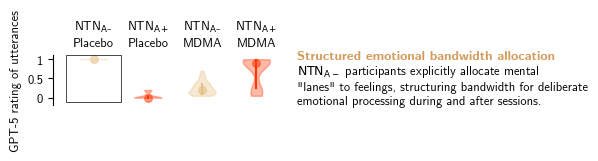


--------------------------------------------------------------------------------
GPT-5 FEATURES FOR HIGH BIOTYPE DURING PLACEBO
--------------------------------------------------------------------------------


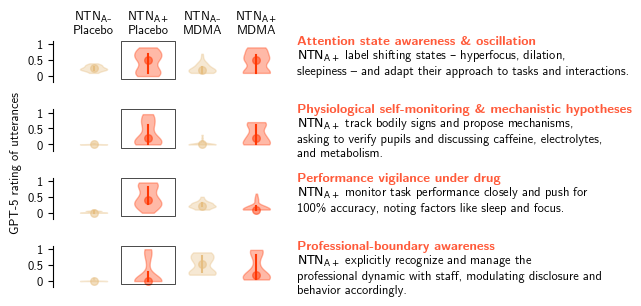


--------------------------------------------------------------------------------
GPT-5 FEATURES FOR LOW BIOTYPE DURING MDMA_HIGH
--------------------------------------------------------------------------------


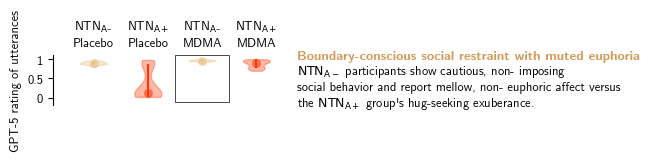


--------------------------------------------------------------------------------
GPT-5 FEATURES FOR HIGH BIOTYPE DURING MDMA_HIGH
--------------------------------------------------------------------------------


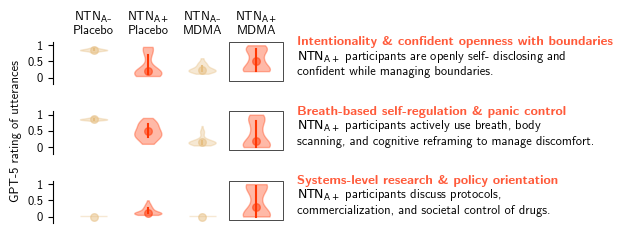

In [14]:
for condition in conditions:
    for biotype in biotypes:
        
        gpt_vars = gpt_top_features[condition][biotype]

        print("-"*80 + f"\nGPT-5 FEATURES FOR {biotype.upper()} BIOTYPE DURING {condition.upper()}\n" + "-"*80)
        fig, axes = plt.subplots(len(gpt_vars), 1, figsize=(3.5, len(gpt_vars)*0.85-0.2), squeeze=False)
        for var_i, var in enumerate(gpt_vars):
            for session_i, session in enumerate(sorted(set(speech_line_df["session"]))):
                
                session_df = speech_line_df[speech_line_df["session"] == session]
                session_biotype = session_df["biotype"].values[0]
                session_condition = session_df["condition"].values[0]
                c = visualize.biotype2color[session_biotype]
                
                p = axes[var_i,0].violinplot(session_df[var], positions=[session_i])
                for pc in p["bodies"]:
                    pc.set_facecolor(c)
                    pc.set_alpha(0.35)
                    pc.set_edgecolor(c)
                for partname in ("cbars", "cmins", "cmaxes"):
                    vp = p[partname]
                    vp.set_linewidth(0)
                    
                axes[var_i,0].plot([session_i, session_i], 
                                    [session_df[var].quantile(0.25), session_df[var].quantile(0.75)], c=c)
                axes[var_i,0].scatter([session_i], [session_df[var].median()], c=c, s=30, linewidth=1,
                                      alpha=0.5)

                if var_i == 0:
                    axes[var_i,0].text(session_i, 1.75, visualize.biotype2title[session_biotype], ha="center",
                                        font=font_manager.FontProperties(fname=visualize.font_path, size=9))
                    axes[var_i,0].text(session_i, 1.35, visualize.condition2title[session_condition], ha="center",
                                        font=font_manager.FontProperties(fname=visualize.font_path, size=9))

                if condition == session_condition and biotype == session_biotype:
                    square = patches.Rectangle(xy=(session_i-0.5, -0.1), width=1, height=1.2,
                                               fill=False, edgecolor="black", linewidth=0.5)
                    axes[var_i,0].add_patch(square)

            title = featurize.format_gpt_title(features[condition][biotype]["titles"][var], width=60)
            axes[var_i,0].text(3.75, 1, title, c=biotype2color[biotype],
                             font=font_manager.FontProperties(fname=visualize.font_bold_path, size=9.5))
    
            text = featurize.format_gpt_description(features[condition][biotype]["descriptions"][var], biotype, width=55)
            text = "\n".join(textwrap.wrap(text, width=65))
            axes[var_i,0].text(3.75, 0.9, text, c="black", va="top",
                             font=font_manager.FontProperties(fname=visualize.font_path, size=9))
            
            axes[var_i,0].spines["top"].set_visible(False)
            axes[var_i,0].spines["bottom"].set_visible(False)
            axes[var_i,0].spines["right"].set_visible(False)

            axes[var_i,0].set_xlim([-0.75, 4.25])
            axes[var_i,0].set_xticks([])
            axes[var_i,0].set_ylim([-0.2, 1.1])
            axes[var_i,0].set_yticks([0, 0.5, 1])
            axes[var_i,0].set_yticklabels([0, 0.5, 1], 
                                          font=font_manager.FontProperties(fname=visualize.font_path, size=9))

        fig.supylabel("GPT-5 rating of utterances", x=0.0025, 
                      font=font_manager.FontProperties(fname=visualize.font_path, size=9))
        
        plt.subplots_adjust(hspace=0.65, wspace=0.85)
        plt.savefig(f"{figure_path}/synthetic_transcripts_{condition}_{biotype}.png", dpi=300, bbox_inches="tight")
        plt.show()
        print()

### Neurolinguistic reports

Each of the below figures represents what a speech signature report would look like for an individual participating in a placebo or MDMA session. We expect that ratings will be highest for the features corresponding to the individual's biotype assignment, which are the features denoted here with black box outlines.

----------------------------------------------------------------------------------------------------
SPEECH SIGNATURE REPORT FOR INDIVIDUAL P001
----------------------------------------------------------------------------------------------------


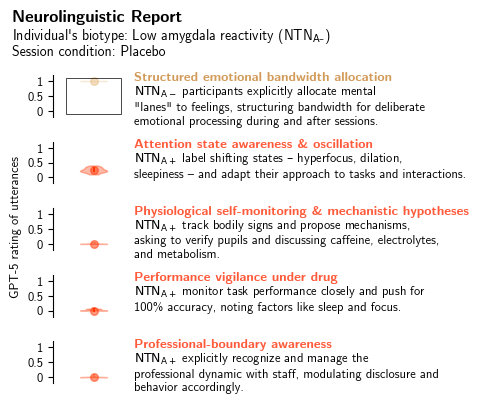


----------------------------------------------------------------------------------------------------
SPEECH SIGNATURE REPORT FOR INDIVIDUAL P002
----------------------------------------------------------------------------------------------------


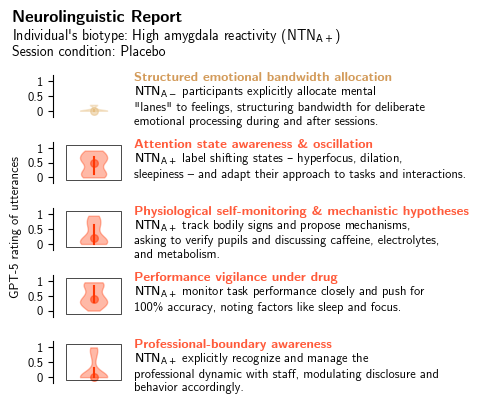


----------------------------------------------------------------------------------------------------
SPEECH SIGNATURE REPORT FOR INDIVIDUAL P003
----------------------------------------------------------------------------------------------------


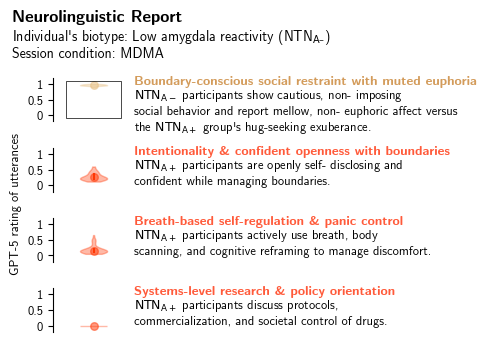


----------------------------------------------------------------------------------------------------
SPEECH SIGNATURE REPORT FOR INDIVIDUAL P004
----------------------------------------------------------------------------------------------------


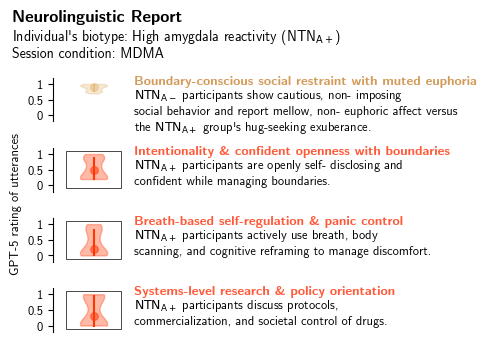

In [15]:
var2biotype = {}
for condition in conditions:
    for biotype in biotypes:
        for var in gpt_top_features[condition][biotype]:
            var2biotype[var] = biotype

for session in sorted(set(speech_line_df["session"])):
    
    session_df = speech_line_df[speech_line_df["session"] == session]
    session_biotype = session_df["biotype"].values[0]
    session_condition = session_df["condition"].values[0]
    
    print("-"*100 + f"\nSPEECH SIGNATURE REPORT FOR INDIVIDUAL {session.split("_")[0]}\n" + "-" * 100)
    
    gpt_vars = gpt_top_features[session_condition]["low"] + gpt_top_features[session_condition]["high"] 

    fig, axes = plt.subplots(len(gpt_vars), 1, figsize=(3.5, len(gpt_vars)*0.7 + 0.5), squeeze=False)
    
    axes[0,0].text(-1.5, 3, "Neurolinguistic Report", ha="left",
                   font=font_manager.FontProperties(fname=visualize.font_bold_path, size=12))
    axes[0,0].text(-1.5, 2.4, f"Individual's biotype: {session_biotype.title()} amygdala reactivity ({visualize.biotype2title[session_biotype]})", ha="left",
                   font=font_manager.FontProperties(fname=visualize.font_path, size=10))
    axes[0,0].text(-1.5, 1.85, f"Session condition: {visualize.condition2title[session_condition]}", ha="left",
                   font=font_manager.FontProperties(fname=visualize.font_path, size=10))

    for var_i, var in enumerate(gpt_vars):
        
        c = visualize.biotype2color[var2biotype[var]]        
        p = axes[var_i,0].violinplot(session_df[var], positions=[0])
        for pc in p["bodies"]:
            pc.set_facecolor(c)
            pc.set_alpha(0.35)
            pc.set_edgecolor(c)
        for partname in ("cbars", "cmins", "cmaxes"):
            vp = p[partname]
            vp.set_linewidth(0)
            
        axes[var_i,0].plot([0, 0], 
                            [session_df[var].quantile(0.25), session_df[var].quantile(0.75)], c=c)
        axes[var_i,0].scatter([0], [session_df[var].median()], c=c, s=30, linewidth=1,
                              alpha=0.5)

        if session_biotype == var2biotype[var]:
            square = patches.Rectangle(xy=(-0.5, -0.1), width=1, height=1.2,
                                       fill=False, edgecolor="black", linewidth=0.5)
            axes[var_i,0].add_patch(square)

        var2title = {var: title for var, title in features[session_condition]["low"]["titles"].items()} | {var: title for var, title in features[session_condition]["high"]["titles"].items()}
        title = featurize.format_gpt_title(var2title[var], width=60)
        axes[var_i,0].text(0.75, 1, title, c=biotype2color[var2biotype[var]],
                         font=font_manager.FontProperties(fname=visualize.font_bold_path, size=9.5))

        var2text = {var: text for var, text in features[session_condition]["low"]["descriptions"].items()} | {var: text for var, text in features[session_condition]["high"]["descriptions"].items()}
        text = featurize.format_gpt_description(var2text[var], biotype, width=55)
        text = "\n".join(textwrap.wrap(text, width=65))
        axes[var_i,0].text(0.75, 0.9, text, c="black", va="top",
                         font=font_manager.FontProperties(fname=visualize.font_path, size=9))
        
        axes[var_i,0].spines["top"].set_visible(False)
        axes[var_i,0].spines["bottom"].set_visible(False)
        axes[var_i,0].spines["right"].set_visible(False)

        axes[var_i,0].set_xlim([-0.75, 4.25])
        axes[var_i,0].set_xticks([])
        axes[var_i,0].set_ylim([-0.2, 1.2])
        axes[var_i,0].set_yticks([0, 0.5, 1])
        axes[var_i,0].set_yticklabels([0, 0.5, 1], 
                                      font=font_manager.FontProperties(fname=visualize.font_path, size=9))

    fig.supylabel("GPT-5 rating of utterances", x=0.0025, 
                  font=font_manager.FontProperties(fname=visualize.font_path, size=9))
    
    plt.subplots_adjust(hspace=0.6, wspace=0.85)
    plt.savefig(f"{figure_path}/synthetic_transcripts_{session}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print()